In [1]:
print("Hello, JupyterLab!")

Hello, JupyterLab!


    column1   column2
0  0.908976  2.169419
1  0.308743  3.503377
2  0.813250  1.751134
3  0.454275  9.622268
4  0.141802  1.489547


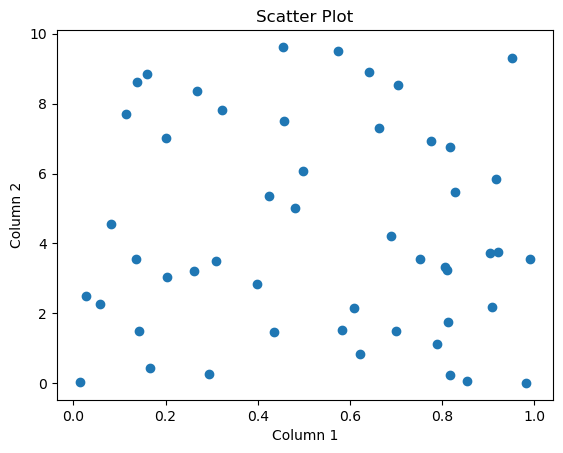

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create a sample DataFrame
data = pd.DataFrame({
    "column1": np.random.rand(50),  # 50 random values for column1
    "column2": np.random.rand(50) * 10  # 50 random values (multiplied by 10) for column2
})

# Display the first few rows
print(data.head())

# Create a scatter plot
plt.scatter(data["column1"], data["column2"])
plt.xlabel("Column 1")
plt.ylabel("Column 2")
plt.title("Scatter Plot")
plt.show()

In [3]:
import pandas as pd

data = pd.read_csv("/home/prakash/Desktop/demo_dataset.csv")
print(data.head())
print(data.info())
print(data.isnull().sum())


   log_id       source_ip destination_port protocol bytes_transferred  \
0      10      10.0.0.100      STRING_PORT      FTP              4096   
1      12  172.16.254.100              110     POP3          NEGATIVE   
2      27  172.16.254.200              110     POP3       NON_NUMERIC   
3       1   192.168.1.100               80     HTTP              1024   
4       2    192.168.1.81               53      TLS              9765   

  threat_level  
0            ?  
1            1  
2            1  
3            0  
4            0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   log_id             100 non-null    int64 
 1   source_ip          99 non-null     object
 2   destination_port   99 non-null     object
 3   protocol           100 non-null    object
 4   bytes_transferred  100 non-null    object
 5   threat_level       100

In [4]:
print(data.head())


   log_id       source_ip destination_port protocol bytes_transferred  \
0      10      10.0.0.100      STRING_PORT      FTP              4096   
1      12  172.16.254.100              110     POP3          NEGATIVE   
2      27  172.16.254.200              110     POP3       NON_NUMERIC   
3       1   192.168.1.100               80     HTTP              1024   
4       2    192.168.1.81               53      TLS              9765   

  threat_level  
0            ?  
1            1  
2            1  
3            0  
4            0  


In [5]:
import re

def is_valid_ip(ip):
    pattern = re.compile(r'^((25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)\.){3}(25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)$')
    return bool(pattern.match(str(ip)))

def is_valid_port(port):
    try:
        return 0 <= int(port) <= 65535
    except ValueError:
        return False

def is_valid_bytes(bytes):
    try:
        return int(bytes) >= 0
    except ValueError:
        return False

def is_valid_threat_level(threat_level):
    try:
        return 0 <= int(threat_level) <= 2
    except ValueError:
        return False

invalid_ips = data[~data['source_ip'].astype(str).apply(is_valid_ip)]
invalid_ports = data[~data['destination_port'].apply(is_valid_port)]
invalid_bytes = data[~data['bytes_transferred'].apply(is_valid_bytes)]
invalid_threat_levels = data[~data['threat_level'].apply(is_valid_threat_level)]

print(invalid_ips)
print(invalid_ports)
print(invalid_bytes)
print(invalid_threat_levels)

    log_id       source_ip destination_port protocol bytes_transferred  \
40      41      10.0.0.300               25     SMTP              4096   
51      52    10.10.10.450      STRING_PORT      FTP              4096   
55      56             NaN               53      DNS              1024   
57      58   192.168.1.475              NaN      UDP              2048   
63      64      MISSING_IP               53      DNS              1024   
65      66   192.168.1.600      UNUSED_PORT      UDP              2048   
71      72      MISSING_IP               53      DNS              1024   
74      75    172.16.1.400               80     HTTP              1024   
82      83    172.16.1.450               80     HTTP              1024   
87      88      MISSING_IP               53      DNS              1024   
88      89    10.10.10.700              443      TLS               512   
92      93      INVALID_IP              110     POP3              4096   
93      94  192.168.1.1050            

In [6]:
import numpy as np
from sklearn.impute import SimpleImputer

df = pd.read_csv("/home/prakash/Desktop/demo_dataset.csv")

df.replace(['INVALID_IP','MISSING_IP','STRING_PORT','UNUSED_PORT','NON_NUMERIC','NEGATIVE','?'], np.nan, inplace=True)

df['destination_port'] = pd.to_numeric(df['destination_port'], errors='coerce')
df['bytes_transferred'] = pd.to_numeric(df['bytes_transferred'], errors='coerce')
df['threat_level'] = pd.to_numeric(df['threat_level'], errors='coerce')

numeric_cols = ['destination_port', 'bytes_transferred', 'threat_level']
categorical_cols = ['protocol']

num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

df['source_ip'] = df['source_ip'].fillna('0.0.0.0')
df['destination_port'] = df['destination_port'].clip(lower=0, upper=65535)

print(df.describe(include='all'))

            log_id source_ip  destination_port protocol  bytes_transferred  \
count   100.000000       100        100.000000      100          100.00000   
unique         NaN        85               NaN       10                NaN   
top            NaN   0.0.0.0               NaN     HTTP                NaN   
freq           NaN         6               NaN       25                NaN   
mean     50.500000       NaN        776.860000      NaN         4138.64000   
std      29.011492       NaN       6542.582099      NaN         2526.40978   
min       1.000000       NaN         22.000000      NaN          498.00000   
25%      25.750000       NaN         53.000000      NaN         1693.25000   
50%      50.500000       NaN         80.000000      NaN         4096.00000   
75%      75.250000       NaN        110.000000      NaN         5971.75000   
max     100.000000       NaN      65535.000000      NaN         9765.00000   

        threat_level  
count     100.000000  
unique           

In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit_transform(df[['protocol']])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['protocol']))
df = pd.concat([df.drop('protocol', axis=1), encoded_df], axis=1)

# Log transform bytes_transferred
df["bytes_transferred"] = np.log1p(df["bytes_transferred"])

print(df.head())

   log_id       source_ip  destination_port  bytes_transferred  threat_level  \
0      10      10.0.0.100              80.0           8.318010           1.0   
1      12  172.16.254.100             110.0           8.318010           1.0   
2      27  172.16.254.200             110.0           8.318010           1.0   
3       1   192.168.1.100              80.0           6.932448           0.0   
4       2    192.168.1.81              53.0           9.186662           0.0   

   protocol_DNS  protocol_FTP  protocol_HTTP  protocol_HTTPS  protocol_POP3  \
0           0.0           1.0            0.0             0.0            0.0   
1           0.0           0.0            0.0             0.0            1.0   
2           0.0           0.0            0.0             0.0            1.0   
3           0.0           0.0            1.0             0.0            0.0   
4           0.0           0.0            0.0             0.0            0.0   

   protocol_SMTP  protocol_SSH  protocol_TLS

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop("threat_level", axis=1)
y = df["threat_level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1337)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1337)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 60, Val: 20, Test: 20


In [9]:
import requests
import zipfile
import io
import os

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
response = requests.get(url)
if response.status_code == 200:
    print("Download successful")
else:
    print("Failed to download the dataset")

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("sms_spam_collection")
    print("Extraction successful")

print("Extracted files:", os.listdir("sms_spam_collection"))

Download successful
Extraction successful
Extracted files: ['SMSSpamCollection', 'readme']


In [10]:
import pandas as pd

df = pd.read_csv(
    "sms_spam_collection/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"],
)

print("-------------------- HEAD --------------------")
print(df.head())
print("-------------------- DESCRIBE --------------------")
print(df.describe())
print("-------------------- INFO --------------------")
print(df.info())
print("Missing values:\n", df.isnull().sum())
print("Duplicate entries:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

-------------------- HEAD --------------------
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
-------------------- DESCRIBE --------------------
       label                 message
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30
-------------------- INFO --------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
Missing values:


In [11]:
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download required NLTK data
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

print("=== BEFORE ANY PREPROCESSING ===")
print(df.head(5))

# Step 1 - Lowercase
df["message"] = df["message"].str.lower()
print("\n=== AFTER LOWERCASING ===")
print(df["message"].head(5))

# Step 2 - Remove punctuation/numbers (keep $ and !)
df["message"] = df["message"].apply(lambda x: re.sub(r"[^a-z\s$!]", "", x))
print("\n=== AFTER REMOVING PUNCTUATION & NUMBERS ===")
print(df["message"].head(5))

# Step 3 - Tokenize
df["message"] = df["message"].apply(word_tokenize)
print("\n=== AFTER TOKENIZATION ===")
print(df["message"].head(5))

# Step 4 - Remove stop words
stop_words = set(stopwords.words("english"))
df["message"] = df["message"].apply(lambda x: [word for word in x if word not in stop_words])
print("\n=== AFTER REMOVING STOP WORDS ===")
print(df["message"].head(5))

# Step 5 - Stemming
stemmer = PorterStemmer()
df["message"] = df["message"].apply(lambda x: [stemmer.stem(word) for word in x])
print("\n=== AFTER STEMMING ===")
print(df["message"].head(5))

# Step 6 - Rejoin tokens
df["message"] = df["message"].apply(lambda x: " ".join(x))
print("\n=== AFTER JOINING TOKENS BACK INTO STRINGS ===")
print(df["message"].head(5))

[nltk_data] Downloading package punkt to /home/prakash/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/prakash/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/prakash/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


=== BEFORE ANY PREPROCESSING ===
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

=== AFTER LOWERCASING ===
0    go until jurong point, crazy.. available only ...
1                        ok lar... joking wif u oni...
2    free entry in 2 a wkly comp to win fa cup fina...
3    u dun say so early hor... u c already then say...
4    nah i don't think he goes to usf, he lives aro...
Name: message, dtype: object

=== AFTER REMOVING PUNCTUATION & NUMBERS ===
0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in  a wkly comp to win fa cup final...
3          u dun say so early hor u c already then say
4    nah i dont 

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(min_df=1, max_df=0.9, ngram_range=(1, 2))
X = vectorizer.fit_transform(df["message"])
y = df["label"].apply(lambda x: 1 if x == "spam" else 0)

print("Feature matrix shape:", X.shape)
print("Spam count:", y.sum())
print("Ham count:", (y == 0).sum())

Feature matrix shape: (5169, 37069)
Spam count: 653
Ham count: 4516


In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("vectorizer", vectorizer),
    ("classifier", MultinomialNB())
])

param_grid = {
    "classifier__alpha": [0.01, 0.1, 0.15, 0.2, 0.25, 0.5, 0.75, 1.0]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="f1")
grid_search.fit(df["message"], y)

best_model = grid_search.best_estimator_
print("Best model parameters:", grid_search.best_params_)

Best model parameters: {'classifier__alpha': 0.25}


In [14]:
import joblib

joblib.dump(best_model, 'spam_detection_model.joblib')
print("Model saved.")

Model saved.


In [15]:
new_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Go to http://bit.ly/1234 to claim now.",
    "Hey, are we still meeting up for lunch today?",
    "Urgent! Your account has been compromised. Verify your details here: www.fakebank.com/verify",
    "Reminder: Your appointment is scheduled for tomorrow at 10am.",
    "FREE entry in a weekly competition to win an iPad. Just text WIN to 80085 now!",
]

def preprocess_message(message):
    message = message.lower()
    message = re.sub(r"[^a-z\s$!]", "", message)
    tokens = word_tokenize(message)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(tokens)

processed_messages = [preprocess_message(msg) for msg in new_messages]
X_new = best_model.named_steps["vectorizer"].transform(processed_messages)
predictions = best_model.named_steps["classifier"].predict(X_new)
prediction_probabilities = best_model.named_steps["classifier"].predict_proba(X_new)

for i, msg in enumerate(new_messages):
    prediction = "Spam" if predictions[i] == 1 else "Not-Spam"
    print(f"Message: {msg}")
    print(f"Prediction: {prediction}")
    print(f"Spam Probability: {prediction_probabilities[i][1]:.2f}")
    print(f"Not-Spam Probability: {prediction_probabilities[i][0]:.2f}")
    print("-" * 50)

    

Message: Congratulations! You've won a $1000 Walmart gift card. Go to http://bit.ly/1234 to claim now.
Prediction: Spam
Spam Probability: 1.00
Not-Spam Probability: 0.00
--------------------------------------------------
Message: Hey, are we still meeting up for lunch today?
Prediction: Not-Spam
Spam Probability: 0.00
Not-Spam Probability: 1.00
--------------------------------------------------
Message: Urgent! Your account has been compromised. Verify your details here: www.fakebank.com/verify
Prediction: Spam
Spam Probability: 0.96
Not-Spam Probability: 0.04
--------------------------------------------------
Message: Reminder: Your appointment is scheduled for tomorrow at 10am.
Prediction: Not-Spam
Spam Probability: 0.00
Not-Spam Probability: 1.00
--------------------------------------------------
Message: FREE entry in a weekly competition to win an iPad. Just text WIN to 80085 now!
Prediction: Spam
Spam Probability: 1.00
Not-Spam Probability: 0.00
----------------------------------

In [1]:
import requests
import json

url = "http://10.129.128.206:8000/api/upload"
model_file_path = "spam_detection_model.joblib"

with open(model_file_path, "rb") as model_file:
    files = {"model": model_file}
    response = requests.post(url, files=files)

print(json.dumps(response.json(), indent=4))

{
    "accuracy": 0.9130434782608695,
    "flag": "HTB{sp4m_cla55if13r_3v4lu4t0r}"
}
